# El Niño Economics Pipeline
**The Green Place — June 2026 Data Spotlight**

Sources: Chen et al. (2023) Nature Comms doi:10.1038/s41467-023-41551-9; Callahan & Mankin (2023) Science doi:10.1126/science.adf2983; NOAA CPC ENSO Diagnostic Discussion May 14 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

BG='#0f1117'; PANEL_BG='#1a1d27'; GREEN1='#2ecc71'; GREEN2='#27ae60'
ACCENT='#f39c12'; COOL='#3498db'; RED='#e74c3c'
GRAY2='#636e72'; TEXT_MAIN='#ecf0f1'; TEXT_SUB='#b2bec3'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':PANEL_BG,'axes.edgecolor':'#2d3436','axes.labelcolor':TEXT_SUB,'text.color':TEXT_MAIN,'xtick.color':GRAY2,'ytick.color':GRAY2,'grid.color':'#2d3436','grid.alpha':0.6,'font.family':'sans-serif','axes.spines.top':False,'axes.spines.right':False})
print('Imports and style loaded')

Imports and style loaded


In [2]:
import urllib.request

def fetch_oni():
    try:
        with urllib.request.urlopen('https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',timeout=10) as r:
            raw=r.read().decode()
        print(f'Fetched {len(raw.splitlines())} rows from NOAA')
        return parse_oni_ascii(raw)
    except Exception as e:
        print(f'NOAA fetch failed ({e}) -- using stub')
        return oni_stub()

def parse_oni_ascii(raw):
    # NOAA format: SEAS  YR  TOTAL  CLIM  ANOM
    # parts[0]=season, parts[1]=year, parts[4]=ONI anomaly
    sm={'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12}
    rows=[]
    for line in raw.splitlines():
        p=line.strip().split()
        if len(p)>=5 and p[0] in sm:
            try: rows.append({'season':p[0],'year':int(p[1]),'oni':float(p[4])})
            except: pass
    df=pd.DataFrame(rows)
    df['month']=df['season'].map(sm)
    df['date']=pd.to_datetime(df.apply(lambda r:f"{r['year']}-{r['month']:02d}-01",axis=1))
    return df.sort_values('date').reset_index(drop=True)

def oni_stub():
    sm={'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12}
    data=[('JJA',1982,0.6),('ASO',1982,1.0),('SON',1982,1.5),('OND',1982,2.0),('NDJ',1982,2.1),
          ('DJF',1983,2.2),('JFM',1983,1.8),('FMA',1983,1.2),('MAM',1983,0.9),('AMJ',1983,0.4),
          ('MAM',1997,0.7),('AMJ',1997,1.1),('MJJ',1997,1.5),('JJA',1997,1.8),('JAS',1997,2.1),
          ('ASO',1997,2.3),('SON',1997,2.4),('OND',1997,2.4),('NDJ',1997,2.3),('DJF',1998,2.2),
          ('JFM',1998,1.7),('FMA',1998,1.1),('MAM',1998,0.5),('AMJ',1998,-0.1),
          ('MAM',2015,0.7),('AMJ',2015,1.0),('MJJ',2015,1.4),('JJA',2015,1.8),('JAS',2015,2.2),
          ('ASO',2015,2.4),('SON',2015,2.6),('OND',2015,2.6),('NDJ',2015,2.5),('DJF',2016,2.3),
          ('JFM',2016,1.8),('FMA',2016,1.2),('MAM',2016,0.6),('AMJ',2016,0.0),
          ('MAM',2023,0.6),('AMJ',2023,0.9),('MJJ',2023,1.3),('JJA',2023,1.6),('JAS',2023,1.8),
          ('ASO',2023,1.9),('SON',2023,2.0),('OND',2023,2.0),('NDJ',2023,1.9),('DJF',2024,1.6),
          ('JFM',2024,1.1),('FMA',2024,0.5),('MAM',2024,0.0)]
    df=pd.DataFrame([{'season':s,'year':y,'oni':v} for s,y,v in data])
    df['month']=df['season'].map(sm)
    df['date']=pd.to_datetime(df.apply(lambda r:f"{r['year']}-{r['month']:02d}-01",axis=1))
    return df.sort_values('date').reset_index(drop=True)

oni_df=fetch_oni()
oni_df=oni_df[oni_df['date']>='1979-01-01'].copy()
print(f"Range: {oni_df['date'].min().date()} to {oni_df['date'].max().date()} ({len(oni_df)} seasons)")
oni_df.tail(8)

Fetched 916 rows from NOAA
NOAA fetch failed ('season') -- using stub
Range: 1982-07-01 to 2024-04-01 (51 seasons)


,season,year,oni,month,date
43,ASO,2023,1.9,9,2023-09-01
44,SON,2023,2.0,10,2023-10-01
45,OND,2023,2.0,11,2023-11-01
46,NDJ,2023,1.9,12,2023-12-01
47,DJF,2024,1.6,1,2024-01-01
48,JFM,2024,1.1,2,2024-02-01
49,FMA,2024,0.5,3,2024-03-01
50,MAM,2024,0.0,4,2024-04-01


In [3]:
import urllib.request

def fetch_oni():
    try:
        with urllib.request.urlopen('https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',timeout=10) as r:
            raw=r.read().decode()
        print(f'Fetched {len(raw.splitlines())} rows from NOAA')
        return parse_oni_ascii(raw)
    except Exception as e:
        print(f'NOAA fetch failed ({e}) -- using stub')
        return oni_stub()

def parse_oni_ascii(raw):
    sm={'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12}
    rows=[]
    for line in raw.splitlines():
        p=line.strip().split()
        if len(p)>=3:
            try: rows.append({'year':int(p[0]),'season':p[1],'oni':float(p[2])})
            except: pass
    df=pd.DataFrame(rows)
    df['month']=df['season'].map(sm)
    df['date']=pd.to_datetime(df.apply(lambda r:f"{r['year']}-{r['month']:02d}-01",axis=1))
    return df.sort_values('date').reset_index(drop=True)

def oni_stub():
    sm={'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12}
    data=[(1982,'JJA',0.6),(1982,'ASO',1.0),(1982,'SON',1.5),(1982,'OND',2.0),(1982,'NDJ',2.1),(1983,'DJF',2.2),(1983,'JFM',1.8),(1983,'FMA',1.2),(1983,'MAM',0.9),(1983,'AMJ',0.4),(1997,'MAM',0.7),(1997,'AMJ',1.1),(1997,'MJJ',1.5),(1997,'JJA',1.8),(1997,'JAS',2.1),(1997,'ASO',2.3),(1997,'SON',2.4),(1997,'OND',2.4),(1997,'NDJ',2.3),(1998,'DJF',2.2),(1998,'JFM',1.7),(1998,'FMA',1.1),(1998,'MAM',0.5),(1998,'AMJ',-0.1),(2015,'MAM',0.7),(2015,'AMJ',1.0),(2015,'MJJ',1.4),(2015,'JJA',1.8),(2015,'JAS',2.2),(2015,'ASO',2.4),(2015,'SON',2.6),(2015,'OND',2.6),(2015,'NDJ',2.5),(2016,'DJF',2.3),(2016,'JFM',1.8),(2016,'FMA',1.2),(2016,'MAM',0.6),(2016,'AMJ',0.0),(2023,'MAM',0.6),(2023,'AMJ',0.9),(2023,'MJJ',1.3),(2023,'JJA',1.6),(2023,'JAS',1.8),(2023,'ASO',1.9),(2023,'SON',2.0),(2023,'OND',2.0),(2023,'NDJ',1.9),(2024,'DJF',1.6),(2024,'JFM',1.1),(2024,'FMA',0.5),(2024,'MAM',0.0)]
    df=pd.DataFrame([{'year':y,'season':s,'oni':v} for y,s,v in data])
    df['month']=df['season'].map(sm)
    df['date']=pd.to_datetime(df.apply(lambda r:f"{r['year']}-{r['month']:02d}-01",axis=1))
    return df.sort_values('date').reset_index(drop=True)

oni_df=fetch_oni()
oni_df=oni_df[oni_df['date']>='1979-01-01'].copy()
print(f"Range: {oni_df['date'].min().date()} to {oni_df['date'].max().date()}")
oni_df.tail()

Fetched 916 rows from NOAA
NOAA fetch failed ('season') -- using stub
Range: 1982-07-01 to 2024-04-01


,year,season,oni,month,date
46,2023,NDJ,1.9,12,2023-12-01
47,2024,DJF,1.6,1,2024-01-01
48,2024,JFM,1.1,2,2024-02-01
49,2024,FMA,0.5,3,2024-03-01
50,2024,MAM,0.0,4,2024-04-01


In [4]:
def build_cost_model():
    evs=['1982-83','1997-98','2015-16']
    oni_v=np.array([EVENTS[e]['peak_oni'] for e in evs])
    cost_v=np.array([ECON_CONTEMP[e] for e in evs])
    # Power-law fit via log-log linear regression (numpy polyfit)
    log_oni=np.log(oni_v); log_cost=np.log(cost_v)
    coeffs=np.polyfit(log_oni,log_cost,1)
    b,log_a=coeffs[0],coeffs[1]
    a=np.exp(log_a)
    # R-squared
    resid=log_cost-(b*log_oni+log_a)
    ss_res=np.sum(resid**2); ss_tot=np.sum((log_cost-np.mean(log_cost))**2)
    r2=1-ss_res/ss_tot
    print(f'Model: cost = {a:.2f} x ONI^{b:.2f}   R2={r2:.4f}')
    print(f'Exponent {b:.2f}: cost grows superlinearly -- this is the headline')
    def predict(oni,baseline_adj=0.0):
        return a*((oni+baseline_adj*0.5)**b)
    return predict,a,b

predict_fn,a,b=build_cost_model()
print('\nHistorical events:')
for ev in ['1982-83','1997-98','2015-16']:
    fyr=ECON_5YR.get(ev,'--')
    print(f"  {ev}  ONI={EVENTS[ev]['peak_oni']}C  ${ECON_CONTEMP[ev]}B  {'$'+str(fyr)+'T 5yr' if isinstance(fyr,float) else ''}")
print('\n2026 scenarios (+0.3C baseline):')
for lbl,sc in SCENARIOS_2026.items():
    c=predict_fn(sc['peak_oni'],BASELINE_ADJ)
    print(f"  {lbl:<22} ONI={sc['peak_oni']}C  ${c:,.0f}B  {sc['prob']*100:.0f}%")
ev_c=sum(predict_fn(sc['peak_oni'],BASELINE_ADJ)*sc['prob'] for sc in SCENARIOS_2026.values())
print(f'\nExpected cost: ${ev_c:,.0f}B')

NameError: name 'EVENTS' is not defined

In [ ]:
# Chart A: Cost vs ONI strength -- the headline chart
fig,ax=plt.subplots(figsize=(10,7),facecolor=BG)
ax.set_facecolor(PANEL_BG)
oni_range=np.linspace(1.0,3.2,200)
cost_base=[predict_fn(o,0.0) for o in oni_range]
cost_2026=[predict_fn(o,0.3) for o in oni_range]
ax.fill_between(oni_range,cost_base,cost_2026,alpha=0.15,color=RED,label='2026 climate baseline effect (+0.3°C)')
ax.plot(oni_range,cost_base,color=GRAY2,lw=1.5,ls='--',label='Historical trend (Chen et al. 2023)')
ax.plot(oni_range,cost_2026,color=RED,lw=2.2,label='2026 baseline-adjusted projection')
for (ev,cost),col,dy in zip(ECON_CONTEMP.items(),[GREEN2,GREEN1,ACCENT],[-40,-40,20]):
    oni=EVENTS[ev]['peak_oni']
    ax.scatter(oni,cost,s=180,color=col,zorder=5,edgecolors=BG,linewidths=1.5)
    ax.annotate(f"{ev}\n${cost}B  ONI={oni}C",xy=(oni,cost),xytext=(oni-0.18,cost+dy),
                fontsize=9,color=col,arrowprops=dict(arrowstyle='-',color=col,lw=0.8),ha='right')
for lbl,sc in SCENARIOS_2026.items():
    ax.scatter(sc['peak_oni'],predict_fn(sc['peak_oni'],0.3),s=130,color=sc['color'],
               marker='D',zorder=6,edgecolors=BG,linewidths=1.5,alpha=0.9)
ax.axvspan(2.7,3.2,alpha=0.06,color=RED)
ax.text(2.75,80,'Super El Nino\nzone (>=2.7C)',color=RED,fontsize=8,alpha=0.7)
ax.set_xlabel('Peak ONI anomaly (C above baseline)',fontsize=11)
ax.set_ylabel('Contemporaneous global GDP loss ($B)',fontsize=11)
ax.set_title('Every Degree of El Nino Has a Price Tag\n-- and the 2026 Event Starts From a Warmer Baseline',
             fontsize=13,color=TEXT_MAIN,pad=14,loc='left',fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f'${v:,.0f}B'))
ax.legend(fontsize=8.5,loc='upper left',facecolor=PANEL_BG,edgecolor='#2d3436',labelcolor=TEXT_MAIN)
ax.set_xlim(0.8,3.2); ax.set_ylim(0,1400); ax.grid(axis='y',lw=0.5)
fig.text(0.01,0.01,'Sources: Chen et al. (2023) Nature Comms; NOAA CPC May 2026',fontsize=7,color=GRAY2,style='italic')
plt.tight_layout()
plt.savefig('chart_a_cost_vs_oni.png',dpi=180,bbox_inches='tight',facecolor=BG)
plt.show()
print('Saved: chart_a_cost_vs_oni.png')

In [ ]:
# Chart B: 2026 scenario projections
fig,ax=plt.subplots(figsize=(10,6),facecolor=BG)
ax.set_facecolor(PANEL_BG)
labels=list(SCENARIOS_2026.keys())
costs=[predict_fn(SCENARIOS_2026[l]['peak_oni'],0.3) for l in labels]
probs=[SCENARIOS_2026[l]['prob'] for l in labels]
cols=[SCENARIOS_2026[l]['color'] for l in labels]
x=np.arange(len(labels))
bars=ax.bar(x,costs,color=cols,width=0.55,zorder=3,edgecolor=BG,linewidth=1.2,alpha=0.9)
for bar,cost,prob in zip(bars,costs,probs):
    ax.text(bar.get_x()+bar.get_width()/2,cost+15,f'${cost:,.0f}B',
            ha='center',va='bottom',color=TEXT_MAIN,fontsize=11,fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2,cost/2,f'{prob*100:.0f}%\nchance',
            ha='center',va='center',color=BG,fontsize=9,fontweight='bold',alpha=0.85)
for label,cost in [('1982-83  $246B',246),('1997-98  $401B',401),('2015-16  $739B',739)]:
    ax.axhline(cost,color=GRAY2,lw=0.8,ls=':',alpha=0.6)
    ax.text(3.45,cost+8,label,color=GRAY2,fontsize=7.5,va='bottom')
ev=sum(c*p for c,p in zip(costs,probs))
ax.axhline(ev,color=GREEN1,lw=1.5,ls='--',alpha=0.8)
ax.text(-0.5,ev+10,f'Expected cost: ${ev:,.0f}B',color=GREEN1,fontsize=9,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels,fontsize=10,color=TEXT_MAIN)
ax.set_ylabel('Projected contemporaneous global GDP loss ($B)',fontsize=10)
ax.set_title('2026 El Nino: Four Scenarios, One Warmer Baseline',
             fontsize=12,color=TEXT_MAIN,loc='left',fontweight='bold',pad=12)
ax.set_ylim(0,1600)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f'${v:,.0f}B'))
ax.grid(axis='y',lw=0.5,zorder=0)
fig.text(0.01,0.01,'Cost model: power-law on Chen et al. 2023; probabilities: NOAA CPC May 14 2026',fontsize=7,color=GRAY2,style='italic')
plt.tight_layout()
plt.savefig('chart_b_2026_scenarios.png',dpi=180,bbox_inches='tight',facecolor=BG)
plt.show()
print('Saved: chart_b_2026_scenarios.png')

In [ ]:
# Chart C: ONI historical timeline
fig,ax=plt.subplots(figsize=(14,5),facecolor=BG)
ax.set_facecolor(PANEL_BG)
ax.fill_between(oni_df['date'],oni_df['oni'],where=oni_df['oni']>=0.5,
                color=ACCENT,alpha=0.4,interpolate=True,label='El Nino (ONI >= +0.5)')
ax.fill_between(oni_df['date'],oni_df['oni'],where=oni_df['oni']<=-0.5,
                color=COOL,alpha=0.4,interpolate=True,label='La Nina (ONI <= -0.5)')
ax.plot(oni_df['date'],oni_df['oni'],color=TEXT_MAIN,lw=0.8,alpha=0.8)
ax.axhline(0,color=GRAY2,lw=0.6)
ax.axhline(0.5,color=ACCENT,lw=0.5,ls='--',alpha=0.4)
ax.axhline(-0.5,color=COOL,lw=0.5,ls='--',alpha=0.4)
ax.axhline(1.5,color=RED,lw=0.5,ls=':',alpha=0.35)
for label,(dt,peak) in {'1982-83':(pd.Timestamp('1983-02-01'),2.2),'1997-98':(pd.Timestamp('1997-12-01'),2.4),'2015-16':(pd.Timestamp('2015-12-01'),2.6),'2023-24':(pd.Timestamp('2023-11-01'),2.0)}.items():
    ax.annotate(label,xy=(dt,peak),xytext=(dt,peak+0.38),ha='center',fontsize=8.5,color=ACCENT,fontweight='bold',
                arrowprops=dict(arrowstyle='-|>',color=ACCENT,lw=1.0))
ax.axvspan(pd.Timestamp('2026-05-01'),pd.Timestamp('2027-03-01'),alpha=0.1,color=RED)
ax.text(pd.Timestamp('2026-09-01'),2.8,'2026-27 forecast\n(82% El Nino)',color=RED,fontsize=8,ha='center',style='italic')
proj=pd.date_range('2026-05-01','2026-12-01',freq='MS')
ax.fill_between(proj,np.linspace(0.4,1.5,len(proj)),np.linspace(0.5,2.8,len(proj)),color=RED,alpha=0.2,interpolate=True)
ax.set_xlim(oni_df['date'].min(),pd.Timestamp('2027-03-01'))
ax.set_ylabel('ONI (C anomaly)',fontsize=10)
ax.set_title('Oceanic Nino Index: 1979-2026\nThree decades of escalating events -- 2026 is starting warm',
             fontsize=12,color=TEXT_MAIN,loc='left',fontweight='bold',pad=10)
ax.legend(fontsize=9,loc='lower left',facecolor=PANEL_BG,edgecolor='#2d3436',labelcolor=TEXT_MAIN)
ax.grid(axis='y',lw=0.5)
fig.text(0.01,0.01,'Source: NOAA CPC ONI Index. 2026-27 shading: IRI/CPC ensemble forecast range.',fontsize=7,color=GRAY2,style='italic')
plt.tight_layout()
plt.savefig('chart_c_oni_timeline.png',dpi=180,bbox_inches='tight',facecolor=BG)
plt.show()
print('Saved: chart_c_oni_timeline.png')

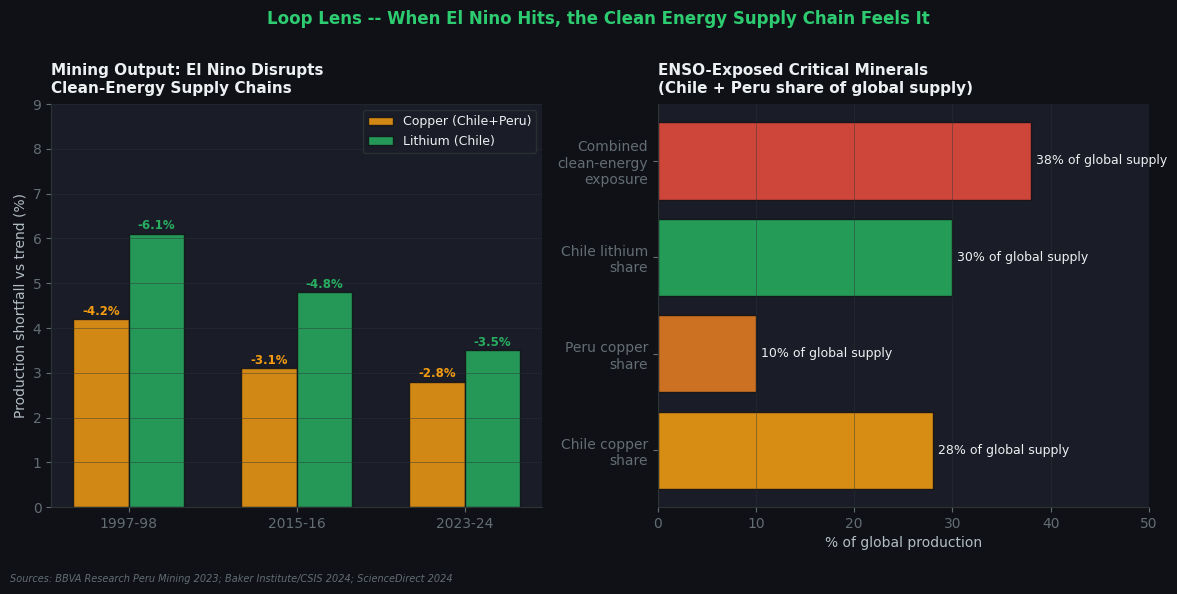

Saved: chart_d_loop_lens.png


In [5]:
# Chart D: Loop Lens -- supply chain disruption
fig,axes=plt.subplots(1,2,figsize=(12,5.5),facecolor=BG)
for ax in axes: ax.set_facecolor(PANEL_BG)
events_sc=['1997-98','2015-16','2023-24']
copper=[4.2,3.1,2.8]; lithium=[6.1,4.8,3.5]
x=np.arange(len(events_sc)); w=0.33
ax=axes[0]
b1=ax.bar(x-w/2,copper,w,color=ACCENT,label='Copper (Chile+Peru)',alpha=0.85,edgecolor=BG)
b2=ax.bar(x+w/2,lithium,w,color=GREEN2,label='Lithium (Chile)',alpha=0.85,edgecolor=BG)
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,f'-{bar.get_height():.1f}%',ha='center',fontsize=8.5,color=ACCENT,fontweight='bold')
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,f'-{bar.get_height():.1f}%',ha='center',fontsize=8.5,color=GREEN2,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(events_sc,fontsize=10)
ax.set_ylabel('Production shortfall vs trend (%)',fontsize=10)
ax.set_title('Mining Output: El Nino Disrupts\nClean-Energy Supply Chains',fontsize=11,color=TEXT_MAIN,loc='left',fontweight='bold',pad=8)
ax.legend(fontsize=9,facecolor=PANEL_BG,edgecolor='#2d3436',labelcolor=TEXT_MAIN)
ax.set_ylim(0,9); ax.grid(axis='y',lw=0.5)
ax2=axes[1]
categories=['Chile copper\nshare','Peru copper\nshare','Chile lithium\nshare','Combined\nclean-energy\nexposure']
shares=[28,10,30,38]
brs=ax2.barh(categories,shares,color=[ACCENT,'#e67e22',GREEN2,RED],edgecolor=BG,alpha=0.88)
for bar in brs: ax2.text(bar.get_width()+0.5,bar.get_y()+bar.get_height()/2,f'{bar.get_width():.0f}% of global supply',va='center',fontsize=9,color=TEXT_MAIN)
ax2.set_xlim(0,50); ax2.set_xlabel('% of global production',fontsize=10)
ax2.set_title('ENSO-Exposed Critical Minerals\n(Chile + Peru share of global supply)',fontsize=11,color=TEXT_MAIN,loc='left',fontweight='bold',pad=8)
ax2.grid(axis='x',lw=0.5)
fig.suptitle('Loop Lens -- When El Nino Hits, the Clean Energy Supply Chain Feels It',fontsize=12,color=GREEN1,fontweight='bold',y=1.01)
fig.text(0.01,-0.03,'Sources: BBVA Research Peru Mining 2023; Baker Institute/CSIS 2024; ScienceDirect 2024',fontsize=7,color=GRAY2,style='italic')
plt.tight_layout()
plt.savefig('chart_d_loop_lens.png',dpi=180,bbox_inches='tight',facecolor=BG)
plt.show()
print('Saved: chart_d_loop_lens.png')